In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


# ResNet Architecture Study

In this section, we study the **ResNet architecture** and investigate how different architectural choices affect the performance of a convolutional neural network.

Unlike the previous architectures, ResNet introduces **residual connections**, which allow information to flow directly from the input of a block to its output. The purpose of this study is to understand how this architectural design behaves as we change specific structural properties of the network.

The experiments will focus on two architectural variables:

1. **Depth** — changing the number of residual blocks.
2. **Width** — changing the number of channels used by the residual blocks.

The experiments will be conducted on the CIFAR-10 classification dataset. To make the comparison meaningful, the training procedure and other conditions will be kept constant while the selected architectural variable is changed.

## ResNet Architecture

The network begins with an initial `1×1` convolution that projects the input from 3 channels to the selected number of channels.

Each residual block contains:

- `3×3` convolution
- ReLU
- `3×3` convolution
- Identity skip connection
- Addition of the residual and identity paths
- ReLU

Max pooling is applied between residual blocks to reduce the spatial dimensions.

The final feature representation is passed through adaptive average pooling and a linear classification layer.

## Experimental Design

### Experiment 1 — Depth

The number of residual blocks will be varied while keeping the width fixed at 64 channels.

- ResNet2
- ResNet3
- ResNet4

The purpose is to investigate how increasing the depth of the network affects learning and generalization.

### Experiment 2 — Width

The number of residual blocks will be fixed at 3 while the number of channels is varied.

- ResNet3-Narrow — 32 channels
- ResNet3-Base — 64 channels
- ResNet3-Wide — 96 channels

The purpose is to investigate how increasing the width of the network affects learning and generalization.

## Controlled Conditions

The following conditions will remain constant across the experiments:

- Dataset: CIFAR-10
- Input size: `32×32`
- Number of classes: 10
- Batch size: 64
- Optimizer: SGD
- Learning rate: 0.01
- Momentum: 0.9
- Loss function: CrossEntropyLoss
- Number of epochs: 20
- Training augmentation: Random Horizontal Flip
- Normalization: CIFAR-10 mean and standard deviation

The goal of this study is not simply to obtain the highest accuracy, but to understand how **depth and width change the behavior of a ResNet architecture** under controlled conditions.

# Experiment 1 — ResNet Depth

In this experiment, we investigate the effect of **network depth** on ResNet performance.

The width of the network is kept constant at **64 channels**, while the number of residual blocks is varied. All other architectural and training conditions are kept constant.

We will compare three models:

- **ResNet2** — 2 residual blocks
- **ResNet3** — 3 residual blocks
- **ResNet4** — 4 residual blocks

| Model | Residual Blocks | Channels |
|---|---:|---:|
| ResNet2 | 2 | 64 |
| ResNet3 | 3 | 64 |
| ResNet4 | 4 | 64 |

The initial `1×1` convolution projects the input from **3 channels to 64 channels**. Each residual block contains two `3×3` convolutional layers with an identity skip connection. Max pooling is applied between residual blocks to reduce the spatial dimensions.

The only architectural variable in this experiment is **depth**, represented by the number of residual blocks.

### Objective

The objective is to determine how increasing the number of residual blocks affects the model's learning and generalization performance.

We will compare the training, validation, and test results of ResNet2, ResNet3, and ResNet4.

In [2]:
!git clone https://github.com/davidmba819/cnn-architecture-study

Cloning into 'cnn-architecture-study'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 45 (delta 17), reused 28 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 2.48 MiB | 11.34 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:
%cd /kaggle/working/cnn-architecture-study

/kaggle/working/cnn-architecture-study


In [4]:
import sys

sys.path.append("/kaggle/working/cnn-architecture-study")

import cnn_utils

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets

In [6]:
DATA_DIR = "/kaggle/input/datasets/pankrzysiu/cifar10-python"

In [7]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=None
)

In [8]:
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


In [9]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [10]:
print(train_transform)
print(eval_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)
Compose(
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)


In [11]:
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [12]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data=train_data,
    val_data=val_data,
    test_data=test_dataset,
    train_transform=train_transform,
    eval_transform=eval_transform,
    batch_size=64,
    num_workers=2
)

In [13]:
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [14]:
class ResidualBlock(nn.Module):
        def __init__(self, in_channels, out_channels, stride=1):
                super().__init__()

                # Main path
                self.conv1 = nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1,
                    stride=stride
                )

                self.relu = nn.ReLU()

                self.conv2 = nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1,
                    stride=stride
                )

                # Identity path
                if in_channels != out_channels or stride != 1:
                    self.shortcut = nn.Conv2d(
                        in_channels,
                        out_channels,
                        kernel_size=1,
                        stride=stride
                    )

                else:
                    self.shortcut = nn.Identity()

        def _initialize_weights(self):

            for layer in self.modules():

                if isinstance(layer, nn.Conv2d):

                    nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

        def forward(self, x):

            identity = self.shortcut(x)
    
            out = self.conv1(x)
            out = self.relu(out)
    
            out = self.conv2(out)
    
            out = out + identity
            out = self.relu(out)
    
            return out

In [15]:
class ResNet(nn.Module):

    def __init__(self, num_blocks=3, width=64):
        super().__init__()

        self.initial = nn.Conv2d(
            in_channels=3,
            out_channels=width,
            kernel_size=1,
            stride=1
        )

        self.relu = nn.ReLU()

        blocks = []

        for _ in range(num_blocks):
            blocks.append(
                ResidualBlock(
                    in_channels=width,
                    out_channels=width,
                    stride=1
                )
            )

        self.blocks = nn.Sequential(*blocks)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(width, 10)
        )

        self._initialize_weights()

    def _initialize_weights(self):

        nn.init.kaiming_normal_(
            self.initial.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        if self.initial.bias is not None:
            nn.init.zeros_(self.initial.bias)

        nn.init.xavier_normal_(
            self.classifier[2].weight
        )

        nn.init.zeros_(
            self.classifier[2].bias
        )

    def forward(self, x):

        x = self.initial(x)
        x = self.relu(x)

        for i, block in enumerate(self.blocks):

            x = block(x)

            if i < len(self.blocks) - 1:
                x = self.pool(x)

        x = self.classifier(x)

        return x

In [16]:
model = ResNet(num_blocks=3, width=64)

x = torch.randn(64, 3, 32, 32)

output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [18]:
model_resnet2 = ResNet(
    num_blocks=2,
    width=64
).to(device)

In [19]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model_resnet2.parameters(),
    lr=0.01,
    momentum=0.9
)

In [20]:
model_resnet2, history_resnet2 = cnn_utils.train_model(
    model=model_resnet2,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.9685 | Train Acc: 0.2555 | Val Loss: 1.7940 | Val Acc: 0.2917
Epoch [2/20] Train Loss: 1.6956 | Train Acc: 0.3615 | Val Loss: 1.6271 | Val Acc: 0.4032
Epoch [3/20] Train Loss: 1.5418 | Train Acc: 0.4325 | Val Loss: 1.4439 | Val Acc: 0.4758
Epoch [4/20] Train Loss: 1.3965 | Train Acc: 0.4944 | Val Loss: 1.3509 | Val Acc: 0.5322
Epoch [5/20] Train Loss: 1.2774 | Train Acc: 0.5415 | Val Loss: 1.2469 | Val Acc: 0.5578
Epoch [6/20] Train Loss: 1.1839 | Train Acc: 0.5782 | Val Loss: 1.2572 | Val Acc: 0.5534
Epoch [7/20] Train Loss: 1.0969 | Train Acc: 0.6119 | Val Loss: 1.0728 | Val Acc: 0.6268
Epoch [8/20] Train Loss: 1.0425 | Train Acc: 0.6306 | Val Loss: 1.0697 | Val Acc: 0.6204
Epoch [9/20] Train Loss: 1.0015 | Train Acc: 0.6441 | Val Loss: 1.0055 | Val Acc: 0.6501
Epoch [10/20] Train Loss: 0.9452 | Train Acc: 0.6669 | Val Loss: 0.9236 | Val Acc: 0.6704
Epoch [11/20] Train Loss: 0.9042 | Train Acc: 0.6857 | Val Loss: 0.9522 | Val Acc: 0.6656
Epoch [12/20] Train

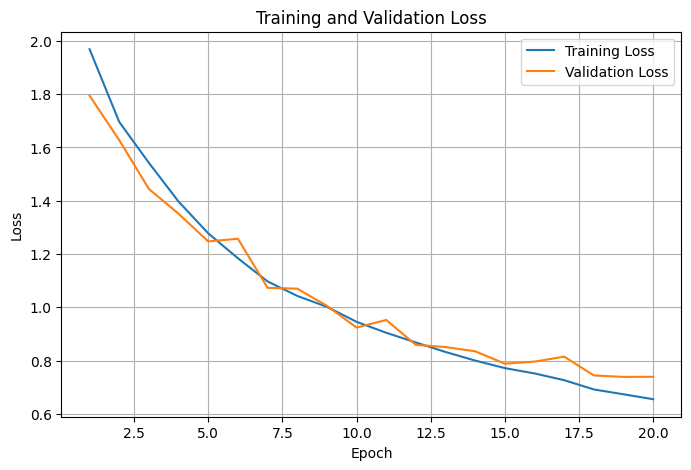

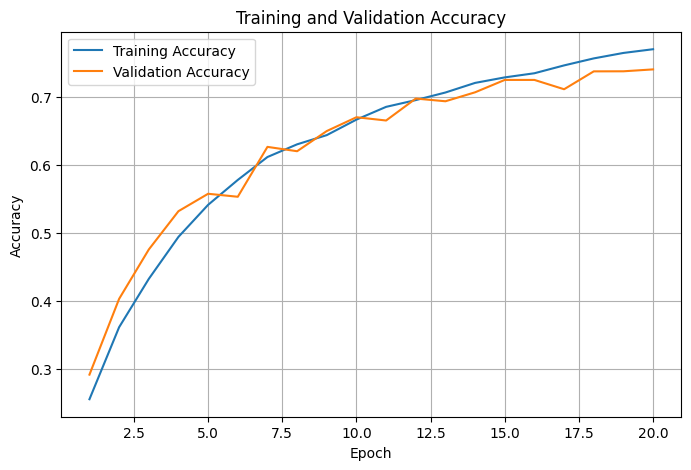

In [21]:
cnn_utils.plot_history(history_resnet2)

In [22]:
test_loss_resnet2, test_accuracy_resnet2 = cnn_utils.test_model(
    model=model_resnet2,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"ResNet2 Test Loss: {test_loss_resnet2:.4f}")
print(f"ResNet2 Test Accuracy: {test_accuracy_resnet2:.2f}%")

Test Loss: 0.7434
Test Accuracy: 0.7446
ResNet2 Test Loss: 0.7434
ResNet2 Test Accuracy: 0.74%


## ResNet2 Results

ResNet2 was trained for 20 epochs using **2 residual blocks** and a fixed width of **64 channels**.

| Metric | Result |
|---|---:|
| Final Training Loss | 0.6547 |
| Final Training Accuracy | 77.05% |
| Final Validation Loss | 0.7388 |
| Final Validation Accuracy | 74.08% |
| Test Loss | 0.7434 |
| Test Accuracy | 74.46% |

The model showed a steady decrease in both training and validation loss throughout training, while training and validation accuracy increased.

The final test accuracy was **74.46%**, providing the baseline result for the depth experiment. This result will be compared with ResNet3 and ResNet4 while keeping the width and training conditions constant.

## ResNet3

The second model in the depth experiment is **ResNet3**, which uses **3 residual blocks** while keeping the network width fixed at **64 channels**.

All other architectural and training conditions remain unchanged from ResNet2. This allows us to examine the effect of adding one additional residual block.

### Configuration

| Parameter | ResNet3 |
|---|---:|
| Residual Blocks | 3 |
| Channels | 64 |
| Epochs | 20 |
| Optimizer | SGD |
| Learning Rate | 0.01 |
| Momentum | 0.9 |
| Loss Function | CrossEntropyLoss |

The model will be trained and evaluated using the same training, validation, and test datasets used for ResNet2.

In [23]:
model_resnet3 = ResNet(
    num_blocks=3,
    width=64
).to(device)

In [24]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model_resnet3.parameters(),
    lr=0.01,
    momentum=0.9
)

In [25]:
model_resnet3, history_resnet3 = cnn_utils.train_model(
    model=model_resnet3,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8791 | Train Acc: 0.2980 | Val Loss: 1.6637 | Val Acc: 0.3910
Epoch [2/20] Train Loss: 1.5106 | Train Acc: 0.4455 | Val Loss: 1.3627 | Val Acc: 0.5066
Epoch [3/20] Train Loss: 1.2883 | Train Acc: 0.5339 | Val Loss: 1.1669 | Val Acc: 0.5756
Epoch [4/20] Train Loss: 1.1284 | Train Acc: 0.5915 | Val Loss: 1.0835 | Val Acc: 0.6156
Epoch [5/20] Train Loss: 1.0132 | Train Acc: 0.6392 | Val Loss: 0.9707 | Val Acc: 0.6612
Epoch [6/20] Train Loss: 0.9217 | Train Acc: 0.6730 | Val Loss: 0.8807 | Val Acc: 0.6920
Epoch [7/20] Train Loss: 0.8447 | Train Acc: 0.7007 | Val Loss: 0.8400 | Val Acc: 0.7016
Epoch [8/20] Train Loss: 0.7668 | Train Acc: 0.7281 | Val Loss: 0.8150 | Val Acc: 0.7098
Epoch [9/20] Train Loss: 0.7175 | Train Acc: 0.7452 | Val Loss: 0.7733 | Val Acc: 0.7170
Epoch [10/20] Train Loss: 0.6591 | Train Acc: 0.7698 | Val Loss: 0.6840 | Val Acc: 0.7567
Epoch [11/20] Train Loss: 0.6205 | Train Acc: 0.7834 | Val Loss: 0.6730 | Val Acc: 0.7657
Epoch [12/20] Train

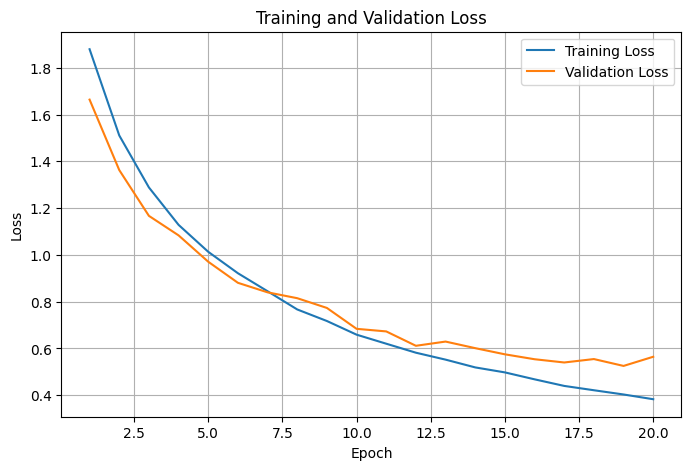

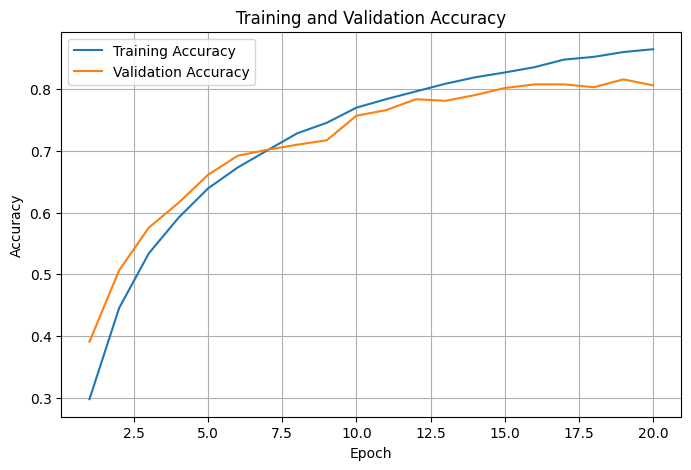

In [26]:
cnn_utils.plot_history(history_resnet3)

In [27]:
test_loss_resnet3, test_accuracy_resnet3 = cnn_utils.test_model(
    model=model_resnet3,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"ResNet3 Test Loss: {test_loss_resnet3:.4f}")
print(f"ResNet3 Test Accuracy: {test_accuracy_resnet3 * 100:.2f}%")

Test Loss: 0.6060
Test Accuracy: 0.8013
ResNet3 Test Loss: 0.6060
ResNet3 Test Accuracy: 80.13%


## ResNet3 Results

ResNet3 was trained for 20 epochs using **3 residual blocks** with a fixed width of **64 channels**. The main purpose of this experiment was to see what happens when one more residual block is added compared with ResNet2, while keeping the width and training settings unchanged.

### Results

| Metric | Result |
|---|---:|
| Final Training Loss | 0.3831 |
| Final Training Accuracy | 86.42% |
| Final Validation Loss | 0.5646 |
| Final Validation Accuracy | 80.58% |
| Test Loss | 0.6060 |
| Test Accuracy | 80.13% |

The model improved steadily throughout the 20 epochs. The training loss decreased from **1.8791** in the first epoch to **0.3831** by the final epoch. At the same time, training accuracy increased from **29.80%** to **86.42%**.

The validation performance also improved during training. Validation accuracy increased from **39.10%** in the first epoch to **80.58%** at the end of training. The validation loss generally decreased as the model learned, although there were some small increases during the later epochs.

Looking at the training and validation curves, the model continued to learn throughout the experiment. However, toward the later epochs, the training accuracy continued to increase while the validation accuracy started to level off around the 80% range. The training loss also continued falling below the validation loss. This shows that the model was fitting the training data more closely than the validation data as training progressed.

The final test accuracy was **80.13%**, with a test loss of **0.6060**. The test result is close to the final validation result of **80.58%**, which suggests that the validation performance gave a reasonable indication of how the model would perform on the unseen test data.

### Comparison with ResNet2

ResNet2 achieved a test accuracy of **74.46%**, while ResNet3 achieved **80.13%**.

This gives an improvement of:

**80.13% − 74.46% = 5.67 percentage points**

Therefore, adding the third residual block produced a noticeable improvement in test performance under the same training conditions.

At this point, the result suggests that increasing the depth from **2 to 3 residual blocks** was useful for this experiment. We will now test ResNet4 to see whether adding another residual block continues to improve the result or whether the improvement starts to level off.

## ResNet4

The final model in the depth experiment is **ResNet4**. This model uses **4 residual blocks**, while the width remains fixed at **64 channels**.

So far, ResNet2 and ResNet3 have given us two different results. ResNet2 achieved a test accuracy of **74.46%**, while adding a third residual block increased the test accuracy to **80.13%**. The purpose of ResNet4 is to find out whether this improvement continues when another residual block is added.

For this experiment, the only thing being changed is the number of residual blocks. The width, dataset, optimizer, learning rate, batch size, loss function, number of epochs, and other training settings remain the same as the previous two models.

### Configuration

| Parameter | ResNet4 |
|---|---:|
| Residual Blocks | 4 |
| Channels | 64 |
| Epochs | 20 |
| Optimizer | SGD |
| Learning Rate | 0.01 |
| Momentum | 0.9 |
| Loss Function | CrossEntropyLoss |

The model will therefore follow the same general structure as the previous models, but with one additional residual block:

```text
Input
  ↓
Initial 1×1 Convolution
  ↓
Residual Block 1
  ↓
Max Pool
  ↓
Residual Block 2
  ↓
Max Pool
  ↓
Residual Block 3
  ↓
Max Pool
  ↓
Residual Block 4
  ↓
Adaptive Average Pooling
  ↓
Linear Classifier
  ↓
10 Classes

In [28]:
model_resnet4 = ResNet(
    num_blocks=4,
    width=64
).to(device)

In [29]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model_resnet4.parameters(),
    lr=0.01,
    momentum=0.9
)

In [30]:
model_resnet4, history_resnet4 = cnn_utils.train_model(
    model=model_resnet4,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7581 | Train Acc: 0.3456 | Val Loss: 1.4737 | Val Acc: 0.4588
Epoch [2/20] Train Loss: 1.3567 | Train Acc: 0.5029 | Val Loss: 1.2478 | Val Acc: 0.5498
Epoch [3/20] Train Loss: 1.1135 | Train Acc: 0.5994 | Val Loss: 0.9904 | Val Acc: 0.6385
Epoch [4/20] Train Loss: 0.9315 | Train Acc: 0.6663 | Val Loss: 0.8939 | Val Acc: 0.6733
Epoch [5/20] Train Loss: 0.8144 | Train Acc: 0.7122 | Val Loss: 0.7485 | Val Acc: 0.7326
Epoch [6/20] Train Loss: 0.7243 | Train Acc: 0.7460 | Val Loss: 0.6918 | Val Acc: 0.7564
Epoch [7/20] Train Loss: 0.6536 | Train Acc: 0.7709 | Val Loss: 0.6564 | Val Acc: 0.7720
Epoch [8/20] Train Loss: 0.5972 | Train Acc: 0.7910 | Val Loss: 0.6285 | Val Acc: 0.7805
Epoch [9/20] Train Loss: 0.5434 | Train Acc: 0.8105 | Val Loss: 0.6087 | Val Acc: 0.7892
Epoch [10/20] Train Loss: 0.5078 | Train Acc: 0.8242 | Val Loss: 0.6300 | Val Acc: 0.7815
Epoch [11/20] Train Loss: 0.4686 | Train Acc: 0.8362 | Val Loss: 0.5685 | Val Acc: 0.8047
Epoch [12/20] Train

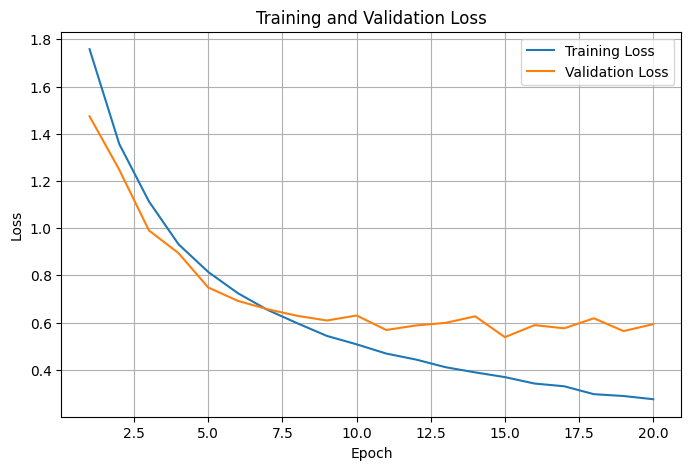

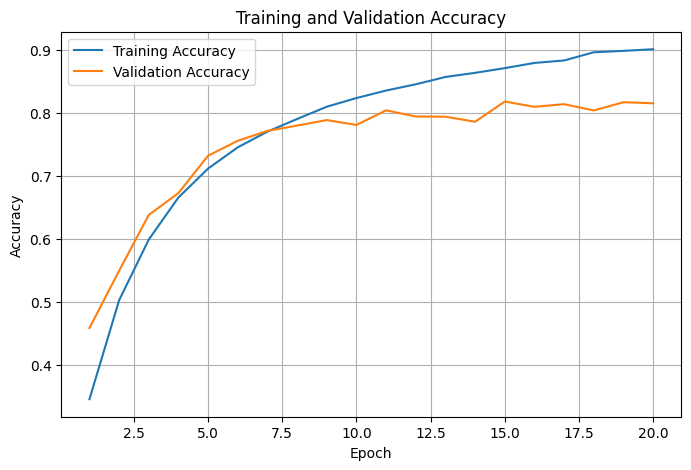

In [31]:
cnn_utils.plot_history(history_resnet4)

In [32]:
test_loss_resnet4, test_accuracy_resnet4 = cnn_utils.test_model(
    model=model_resnet4,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"ResNet4 Test Loss: {test_loss_resnet4:.4f}")
print(f"ResNet4 Test Accuracy: {test_accuracy_resnet4 * 100:.2f}%")


Test Loss: 0.6292
Test Accuracy: 0.8091
ResNet4 Test Loss: 0.6292
ResNet4 Test Accuracy: 80.91%


## ResNet4 Results

ResNet4 was trained for 20 epochs using **4 residual blocks** with the width fixed at **64 channels**. This was the final model in the depth experiment, and its purpose was to determine whether adding a fourth residual block would continue the improvement that we observed when moving from ResNet2 to ResNet3.

### Results

| Metric | Result |
|---|---:|
| Final Training Loss | 0.2752 |
| Final Training Accuracy | 90.18% |
| Final Validation Loss | 0.5931 |
| Final Validation Accuracy | 81.59% |
| Test Loss | 0.6292 |
| Test Accuracy | 80.91% |

The model learned steadily throughout the training process. The training loss decreased from **1.7581** in the first epoch to **0.2752** by the final epoch, while training accuracy increased from **34.56%** to **90.18%**.

The validation performance also improved considerably during the earlier part of training. Validation accuracy increased from **45.88%** in the first epoch and reached **81.59%** by the end of training. However, the validation curves became less stable during the later epochs. While the training accuracy continued to increase, the validation accuracy mostly remained around the 80% range. The validation loss also stopped decreasing consistently and fluctuated during the second half of training.

This difference between the training and validation curves is more noticeable in ResNet4 than it was earlier in the experiment. By the final epoch, the model had reached **90.18% training accuracy**, while the validation accuracy was **81.59%**. This shows that the deeper model was able to fit the training data very well, but the additional depth did not produce a similar increase in validation performance.

The final evaluation on the untouched test set produced a **test loss of 0.6292** and a **test accuracy of 80.91%**.

### Comparison with the Previous Models

The three models in the depth experiment produced the following test results:

| Model | Residual Blocks | Width | Test Loss | Test Accuracy |
|---|---:|---:|---:|---:|
| ResNet2 | 2 | 64 | 0.7434 | 74.46% |
| ResNet3 | 3 | 64 | 0.6060 | 80.13% |
| ResNet4 | 4 | 64 | 0.6292 | 80.91% |

Moving from **ResNet2 to ResNet3** produced a relatively large improvement in test accuracy:

**80.13% − 74.46% = 5.67 percentage points**

When another residual block was added, the test accuracy changed from **80.13% to 80.91%**:

**80.91% − 80.13% = 0.78 percentage points**

Therefore, the increase from 3 to 4 residual blocks produced only a small improvement compared with the much larger improvement obtained from 2 to 3 blocks.

The training results also show that ResNet4 fitted the training data more closely than the previous models. Its final training accuracy of **90.18%** was higher than the **86.42%** achieved by ResNet3 and the **77.05%** achieved by ResNet2. However, this larger increase in training accuracy did not translate into a similarly large increase in test accuracy.

### Observation from the Depth Experiment

Looking at all three models together, increasing the number of residual blocks from **2 to 3** resulted in a clear improvement in test performance. Increasing the depth again from **3 to 4 blocks** still improved the test accuracy, but the improvement was much smaller.

The results from this experiment therefore show that, under the conditions used here, increasing depth was useful up to 4 residual blocks, but the amount of improvement became smaller as more blocks were added.

The final test accuracies were:

- **ResNet2:** 74.46%
- **ResNet3:** 80.13%
- **ResNet4:** 80.91%

The next experiment will keep the depth fixed at **3 residual blocks** and investigate the effect of changing the **width of the network**.

## Experiment 2 — ResNet Width

In the first experiment, we changed the number of residual blocks while keeping the width fixed at 64 channels. In this experiment, we will do the opposite. The number of residual blocks will remain fixed at **3**, while the number of channels used by the network will be changed.

The purpose of this experiment is to see how increasing or decreasing the number of channels affects the model's ability to learn and generalize.

Three models will be compared:

- **ResNet3-Narrow** — 32 channels
- **ResNet3-Base** — 64 channels
- **ResNet3-Wide** — 96 channels

The three models will all contain **3 residual blocks**. The channel width will remain the same across all residual blocks within each model.

### Experimental Configuration

| Model | Residual Blocks | Channels |
|---|---:|---:|
| ResNet3-Narrow | 3 | 32 |
| ResNet3-Base | 3 | 64 |
| ResNet3-Wide | 3 | 96 |

The initial `1×1` convolution will project the input from 3 channels to the selected width. Therefore, the initial projection will be:

- ResNet3-Narrow: `3 → 32`
- ResNet3-Base: `3 → 64`
- ResNet3-Wide: `3 → 96`

The residual blocks will use the same structure in all three models. Only the number of channels will change.

The training conditions will remain the same as in the depth experiment:

- Dataset: CIFAR-10
- Input size: `32×32`
- Batch size: 64
- Epochs: 20
- Optimizer: SGD
- Learning rate: 0.01
- Momentum: 0.9
- Loss function: CrossEntropyLoss

For the comparison, the **ResNet3-Base result from the depth experiment** will be reused because it already represents the 3-block, 64-channel configuration. There is no need to train the same model again.

The main question for this experiment is:

> How does changing the number of channels from 32 to 64 to 96 affect the learning and generalization performance of a 3-block ResNet?

In [33]:
model_resnet3_narrow = ResNet(
    num_blocks=3,
    width=32
).to(device)

In [34]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model_resnet3_narrow.parameters(),
    lr=0.01,
    momentum=0.9
)

In [35]:
model_resnet3_narrow, history_resnet3_narrow = cnn_utils.train_model(
    model=model_resnet3_narrow,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.9279 | Train Acc: 0.2732 | Val Loss: 1.7067 | Val Acc: 0.3604
Epoch [2/20] Train Loss: 1.5833 | Train Acc: 0.4131 | Val Loss: 1.4598 | Val Acc: 0.4445
Epoch [3/20] Train Loss: 1.3961 | Train Acc: 0.4898 | Val Loss: 1.2774 | Val Acc: 0.5478
Epoch [4/20] Train Loss: 1.2306 | Train Acc: 0.5545 | Val Loss: 1.1637 | Val Acc: 0.5862
Epoch [5/20] Train Loss: 1.1224 | Train Acc: 0.5980 | Val Loss: 1.0420 | Val Acc: 0.6289
Epoch [6/20] Train Loss: 1.0221 | Train Acc: 0.6332 | Val Loss: 0.9853 | Val Acc: 0.6485
Epoch [7/20] Train Loss: 0.9551 | Train Acc: 0.6568 | Val Loss: 0.9857 | Val Acc: 0.6482
Epoch [8/20] Train Loss: 0.8933 | Train Acc: 0.6839 | Val Loss: 0.9107 | Val Acc: 0.6799
Epoch [9/20] Train Loss: 0.8391 | Train Acc: 0.7010 | Val Loss: 0.8518 | Val Acc: 0.6975
Epoch [10/20] Train Loss: 0.7931 | Train Acc: 0.7184 | Val Loss: 0.7959 | Val Acc: 0.7189
Epoch [11/20] Train Loss: 0.7564 | Train Acc: 0.7323 | Val Loss: 0.7762 | Val Acc: 0.7221
Epoch [12/20] Train

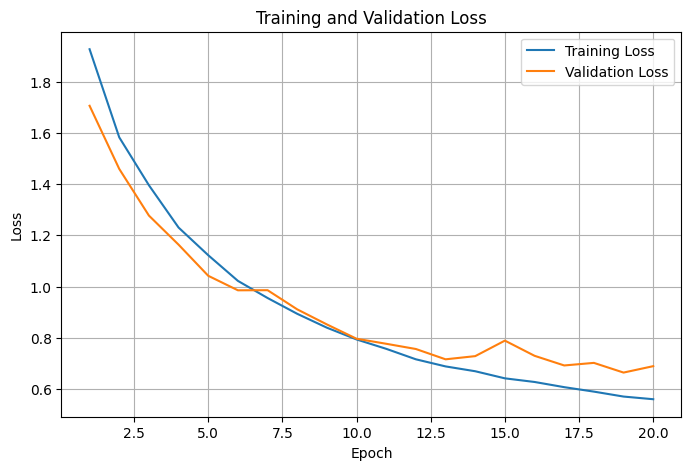

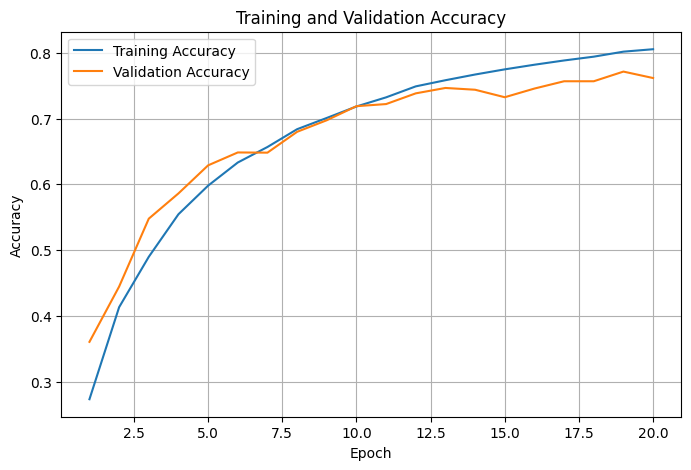

In [36]:
cnn_utils.plot_history(history_resnet3_narrow)

In [37]:
test_loss_resnet3_narrow, test_accuracy_resnet3_narrow = cnn_utils.test_model(
    model=model_resnet3_narrow,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"ResNet3-Narrow Test Loss: {test_loss_resnet3_narrow:.4f}")
print(f"ResNet3-Narrow Test Accuracy: {test_accuracy_resnet3_narrow * 100:.2f}%")

Test Loss: 0.7109
Test Accuracy: 0.7562
ResNet3-Narrow Test Loss: 0.7109
ResNet3-Narrow Test Accuracy: 75.62%


## ResNet3-Narrow Results

ResNet3-Narrow was trained for 20 epochs using **3 residual blocks** with the width reduced to **32 channels**. The purpose of this model was to see what happens when the network is made narrower while keeping the depth fixed at 3 residual blocks.

### Results

| Metric | Result |
|---|---:|
| Final Training Loss | 0.5594 |
| Final Training Accuracy | 80.55% |
| Final Validation Loss | 0.6887 |
| Final Validation Accuracy | 76.17% |
| Test Loss | 0.7109 |
| Test Accuracy | 75.62% |

The model improved consistently during training. The training loss decreased from **1.9279** in the first epoch to **0.5594** by the final epoch. Training accuracy also increased from **27.32%** to **80.55%**.

The validation performance followed a similar pattern. Validation loss decreased from **1.7067** in the first epoch to **0.6887** at the end of training, while validation accuracy increased from **36.04%** to **76.17%**.

Looking at the curves, both training and validation accuracy continued to improve for most of the training process. During the later epochs, the training accuracy continued to increase while the validation accuracy fluctuated around the mid-70% range. The validation loss also showed some fluctuations during the later part of training instead of continuing to decrease consistently. This indicates that the model was continuing to fit the training data, while the improvement on unseen validation data was becoming smaller.

The final evaluation on the untouched test set produced a **test loss of 0.7109** and a **test accuracy of 75.62%**.

### Observation

The main observation from this model is that reducing the width to **32 channels** still allowed the 3-block ResNet to learn the CIFAR-10 classification task reasonably well, but its final performance was lower than the 64-channel ResNet3 model.

The ResNet3-Base model from the depth experiment achieved a test accuracy of **80.13%**, while ResNet3-Narrow achieved **75.62%**.

This gives a difference of:

**80.13% − 75.62% = 4.51 percentage points**

The difference shows that reducing the number of channels from 64 to 32 had a noticeable effect on the model's performance under the same training conditions.

The next model will increase the width to **96 channels** while keeping the number of residual blocks fixed at 3. This will allow us to compare the narrow, base, and wide versions of the same 3-block ResNet.

## ResNet3-Wide

The final model in the width experiment is **ResNet3-Wide**. It uses the same **3 residual blocks** as ResNet3-Narrow and ResNet3-Base, but the number of channels is increased to **96**.

So far, the narrow model has shown that reducing the width to 32 channels resulted in a test accuracy of **75.62%**, while the 64-channel ResNet3-Base achieved **80.13%**. The purpose of ResNet3-Wide is to determine whether increasing the width further to 96 channels will provide another improvement in performance.

The depth remains fixed at 3 residual blocks. The only architectural variable being changed is the number of channels.

### Configuration

| Parameter | ResNet3-Wide |
|---|---:|
| Residual Blocks | 3 |
| Channels | 96 |
| Epochs | 20 |
| Optimizer | SGD |
| Learning Rate | 0.01 |
| Momentum | 0.9 |
| Loss Function | CrossEntropyLoss |

The initial `1×1` convolution will project the input from **3 channels to 96 channels**. All three residual blocks will then operate at 96 channels.

The training and evaluation conditions remain exactly the same as the previous width experiments. This keeps the comparison between the 32-, 64-, and 96-channel models fair.

The main question for this experiment is whether increasing the width from **64 to 96 channels** will allow the model to learn a richer representation and improve its performance on the validation and test sets.

In [38]:
model_resnet3_wide = ResNet(
    num_blocks=3,
    width=96
).to(device)

In [39]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model_resnet3_wide.parameters(),
    lr=0.01,
    momentum=0.9
)

In [40]:
model_resnet3_wide, history_resnet3_wide = cnn_utils.train_model(
    model=model_resnet3_wide,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8558 | Train Acc: 0.3069 | Val Loss: 1.5838 | Val Acc: 0.4036
Epoch [2/20] Train Loss: 1.4697 | Train Acc: 0.4575 | Val Loss: 1.3458 | Val Acc: 0.5195
Epoch [3/20] Train Loss: 1.2680 | Train Acc: 0.5407 | Val Loss: 1.1348 | Val Acc: 0.5957
Epoch [4/20] Train Loss: 1.1145 | Train Acc: 0.5981 | Val Loss: 1.0626 | Val Acc: 0.6217
Epoch [5/20] Train Loss: 0.9951 | Train Acc: 0.6437 | Val Loss: 0.9905 | Val Acc: 0.6422
Epoch [6/20] Train Loss: 0.8948 | Train Acc: 0.6809 | Val Loss: 0.8857 | Val Acc: 0.6843
Epoch [7/20] Train Loss: 0.8156 | Train Acc: 0.7115 | Val Loss: 0.7837 | Val Acc: 0.7235
Epoch [8/20] Train Loss: 0.7367 | Train Acc: 0.7431 | Val Loss: 0.7625 | Val Acc: 0.7304
Epoch [9/20] Train Loss: 0.6797 | Train Acc: 0.7619 | Val Loss: 0.6814 | Val Acc: 0.7554
Epoch [10/20] Train Loss: 0.6234 | Train Acc: 0.7821 | Val Loss: 0.6695 | Val Acc: 0.7630
Epoch [11/20] Train Loss: 0.5832 | Train Acc: 0.7968 | Val Loss: 0.6278 | Val Acc: 0.7717
Epoch [12/20] Train

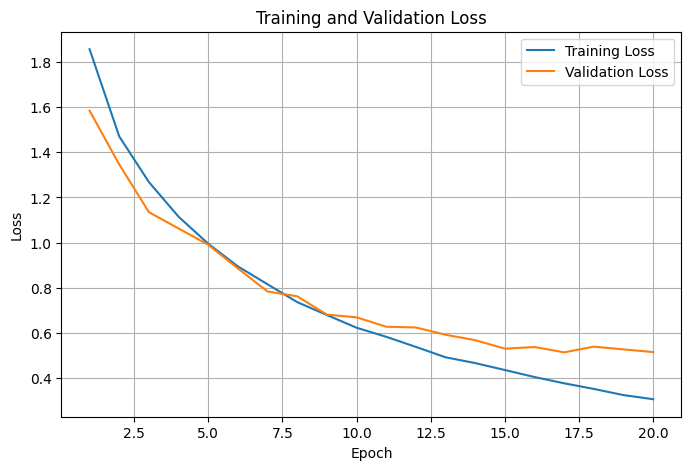

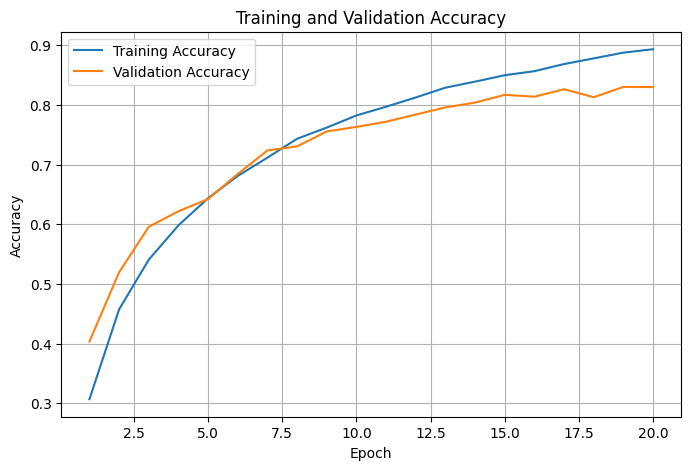

In [41]:
cnn_utils.plot_history(history_resnet3_wide)

In [42]:
test_loss_resnet3_wide, test_accuracy_resnet3_wide = cnn_utils.test_model(
    model=model_resnet3_wide,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"ResNet3-Wide Test Loss: {test_loss_resnet3_wide:.4f}")
print(f"ResNet3-Wide Test Accuracy: {test_accuracy_resnet3_wide * 100:.2f}%")

Test Loss: 0.5453
Test Accuracy: 0.8248
ResNet3-Wide Test Loss: 0.5453
ResNet3-Wide Test Accuracy: 82.48%


## ResNet3-Wide Results

ResNet3-Wide was trained for 20 epochs using **3 residual blocks** with the width increased to **96 channels**. The depth was kept the same as ResNet3-Narrow and ResNet3-Base so that the main difference in this experiment was the number of channels available to the network.

### Results

| Metric | Result |
|---|---:|
| Final Training Loss | 0.3071 |
| Final Training Accuracy | 89.31% |
| Final Validation Loss | 0.5157 |
| Final Validation Accuracy | 82.97% |
| Test Loss | 0.5453 |
| Test Accuracy | 82.48% |

The model showed a steady improvement throughout training. The training loss decreased from **1.8558** in the first epoch to **0.3071** in the final epoch. Training accuracy increased from **30.69%** to **89.31%** over the same period.

Validation performance also improved throughout the experiment. Validation accuracy increased from **40.36%** in the first epoch to **82.97%** at the end of training, while validation loss decreased from **1.5838** to **0.5157**.

The training and validation curves remained relatively close during the earlier part of training. As training continued, the training accuracy kept increasing while the validation accuracy began to level off. By the later epochs, the training accuracy had reached almost 90%, while validation accuracy remained around 82–83%. The same pattern can be seen in the loss curves, where training loss continued to decrease while validation loss showed smaller changes.

The final evaluation on the untouched test set produced a **test loss of 0.5453** and a **test accuracy of 82.48%**.

### Comparison with ResNet3-Narrow and ResNet3-Base

The three models in the width experiment produced the following test results:

| Model | Residual Blocks | Channels | Test Loss | Test Accuracy |
|---|---:|---:|---:|---:|
| ResNet3-Narrow | 3 | 32 | 0.7109 | 75.62% |
| ResNet3-Base | 3 | 64 | 0.6060 | 80.13% |
| ResNet3-Wide | 3 | 96 | 0.5453 | 82.48% |

Increasing the width from **32 to 64 channels** improved the test accuracy by:

**80.13% − 75.62% = 4.51 percentage points**

Increasing the width again from **64 to 96 channels** produced another improvement:

**82.48% − 80.13% = 2.35 percentage points**

Overall, the test accuracy increased from **75.62% with 32 channels** to **82.48% with 96 channels**. This represents a total improvement of:

**82.48% − 75.62% = 6.86 percentage points**

### Observation from the Width Experiment

The results show a consistent improvement in test performance as the width of the 3-block ResNet was increased in this experiment.

The 32-channel model achieved **75.62%**, the 64-channel model achieved **80.13%**, and the 96-channel model achieved **82.48%**.

The increase in width also allowed the models to fit the training data more closely. ResNet3-Narrow finished with **80.55% training accuracy**, ResNet3-Base finished with **86.42%**, and ResNet3-Wide reached **89.31%**.

However, the increase in training accuracy was larger than the increase in test accuracy, especially when moving to the wider model. This can be seen from the growing difference between training and validation performance during the later epochs.

Under the conditions used in this experiment, increasing the number of channels from **32 → 64 → 96** improved both validation and test performance. The next step is to bring the results from the two ResNet experiments together and interpret what we learned about **depth and width**.

# Overall Summary of the ResNet Experiments

The ResNet experiments were carried out to understand how two architectural properties, **depth and width**, affect the performance of a residual convolutional network on the CIFAR-10 classification task.

The experiments were designed so that only one architectural property was changed at a time. In the first experiment, the number of residual blocks was changed while the width was kept fixed at 64 channels. In the second experiment, the number of residual blocks was fixed at 3 while the width was changed from 32 to 64 and then to 96 channels.

The same training conditions were used throughout the experiments, including 20 epochs, SGD with a learning rate of 0.01 and momentum of 0.9, a batch size of 64, and CrossEntropyLoss. The official CIFAR-10 test set was kept separate and was only used for the final evaluation of each model.

## Experiment 1 — Depth

The first experiment compared ResNet2, ResNet3, and ResNet4.

| Model | Residual Blocks | Channels | Test Loss | Test Accuracy |
|---|---:|---:|---:|---:|
| ResNet2 | 2 | 64 | 0.7434 | 74.46% |
| ResNet3 | 3 | 64 | 0.6060 | 80.13% |
| ResNet4 | 4 | 64 | 0.6292 | 80.91% |

Increasing the depth from 2 to 3 residual blocks produced a noticeable improvement. Test accuracy increased from **74.46% to 80.13%**, which is an improvement of **5.67 percentage points**.

When the depth was increased again from 3 to 4 blocks, the test accuracy increased only slightly, from **80.13% to 80.91%**. This was an improvement of just **0.78 percentage points**.

The training results also showed that the deeper models were able to fit the training data more closely. ResNet4 finished with a training accuracy of **90.18%**, compared with **86.42%** for ResNet3 and **77.05%** for ResNet2. However, the increase in training accuracy was much larger than the increase in test accuracy when moving from ResNet3 to ResNet4.

This can also be seen in the training curves. For ResNet4, training accuracy continued to increase during the later epochs, while validation accuracy remained around the 80% range. The validation loss also fluctuated during the later part of training instead of continuing to decrease consistently.

From this experiment, increasing depth from **2 to 3 blocks** had a clear effect on performance, while increasing it from **3 to 4 blocks** resulted in a much smaller change in test accuracy under the conditions used in this study.

## Experiment 2 — Width

The second experiment kept the depth fixed at 3 residual blocks and changed the width of the network.

| Model | Residual Blocks | Channels | Test Loss | Test Accuracy |
|---|---:|---:|---:|---:|
| ResNet3-Narrow | 3 | 32 | 0.7109 | 75.62% |
| ResNet3-Base | 3 | 64 | 0.6060 | 80.13% |
| ResNet3-Wide | 3 | 96 | 0.5453 | 82.48% |

The results showed a consistent increase in test performance as the number of channels increased.

Moving from **32 to 64 channels** increased test accuracy from **75.62% to 80.13%**, giving an improvement of **4.51 percentage points**.

Increasing the width again from **64 to 96 channels** increased test accuracy from **80.13% to 82.48%**, giving another improvement of **2.35 percentage points**.

Across the full width experiment, the test accuracy increased from **75.62% with 32 channels to 82.48% with 96 channels**, giving a total difference of **6.86 percentage points**.

The training results followed the same general pattern. The 32-channel model finished with **80.55% training accuracy**, the 64-channel model reached **86.42%**, and the 96-channel model reached **89.31%**.

However, the wider models also showed a growing difference between training and validation performance toward the later epochs. This means that increasing the number of channels allowed the models to fit the training data more closely, but the increase in test performance was smaller than the increase in training performance.

## Overall Comparison

Putting both experiments together gives the following results:

| Experiment | Model | Main Variable | Test Accuracy |
|---|---|---|---:|
| Depth | ResNet2 | 2 blocks | 74.46% |
| Depth | ResNet3 | 3 blocks | 80.13% |
| Depth | ResNet4 | 4 blocks | 80.91% |
| Width | ResNet3-Narrow | 32 channels | 75.62% |
| Width | ResNet3-Base | 64 channels | 80.13% |
| Width | ResNet3-Wide | 96 channels | 82.48% |

The experiments show that both **depth and width affected the performance of the ResNet models**, but their effects were not identical.

For depth, the largest improvement occurred when moving from **2 to 3 residual blocks**. Adding another block increased the test accuracy only slightly.

For width, the test accuracy increased at every step from **32 → 64 → 96 channels**. The improvement became smaller when moving from 64 to 96 channels, but the wider model still achieved a higher test accuracy.

Another important observation across both experiments is the difference between training performance and generalization performance. Increasing depth or width allowed the models to achieve higher training accuracy, but this did not always translate into an equally large improvement on the validation and test sets. The training curves therefore provide useful information beyond the final accuracy numbers because they show how the models behaved as training progressed.

Overall, these experiments provided a practical comparison of two important ResNet design variables. **Depth controls how many residual transformations are applied, while width controls how many feature channels are available within those transformations.** By changing these variables separately, it was possible to observe how the architecture responded to additional depth and additional feature capacity under the same training conditions.